<a href="https://colab.research.google.com/github/richamudi/Uber-Data-Analytics/blob/main/Uber_Data_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# MODULE 1: IMPORT ALL LIBRARIES
# ============================================================
# Think of this as unpacking your toolbox before starting work.

import numpy as np                # np  → fast maths & arrays
import pandas as pd               # pd  → tables & data manipulation
import matplotlib.pyplot as plt   # plt → basic plotting
import seaborn as sns             # sns → beautiful statistical plots
import warnings                   # suppress non-critical alerts

warnings.simplefilter('ignore')   # hide warning messages so output is clean
sns.set_style('whitegrid')        # give all charts a clean white background with grid

# Quick version check — confirms everything loaded correctly
print("✅ All libraries imported successfully!")
print(f"   NumPy version  : {np.__version__}")
print(f"   Pandas version : {pd.__version__}")
print()
print("Your data science toolkit is ready. Let's build something! 🚀")

✅ All libraries imported successfully!
   NumPy version  : 2.0.2
   Pandas version : 2.2.2

Your data science toolkit is ready. Let's build something! 🚀


In [ ]:
ride_durations = np.array([12, 25, 8, 45, 30, 18, 22, 15, 37, 28])

In [ ]:
np.mean(ride_durations)

np.float64(24.0)

In [ ]:
np.max(ride_durations)

np.int64(45)

In [ ]:
base_fares = np.array([150, 200, 120, 300, 250])

In [ ]:
base_fares*1.5

array([225., 300., 180., 450., 375.])

In [ ]:
sample_data = {
    'RideID':   [101, 102, 103, 104, 105],
    'Pickup':   ['Airport', 'City', 'Airport', 'City', 'Airport'],
    'Duration': [35, 22, 48, 15, 60],
    'Status':   ['Completed', 'Cancelled', 'Completed', 'Completed', 'No Cars']
}

In [ ]:
sample_df = pd.DataFrame(sample_data)

In [ ]:
sample_df

,RideID,Pickup,Duration,Status
0,101,Airport,35,Completed
1,102,City,22,Cancelled
2,103,Airport,48,Completed
3,104,City,15,Completed
4,105,Airport,60,No Cars


In [ ]:
df= pd.read_excel('/content/uber-data.xlsx')

In [ ]:
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,2016-11-07 11:51:00,2016-11-07 13:00:00
1,867,Airport,1.0,Trip Completed,2016-11-07 17:57:00,2016-11-07 18:47:00
2,1807,City,1.0,Trip Completed,2016-12-07 09:17:00,2016-12-07 09:58:00
3,2532,Airport,1.0,Trip Completed,2016-12-07 21:08:00,2016-12-07 22:03:00
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47


In [ ]:
df.shape

(6745, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Request id         6745 non-null   int64         
 1   Pickup point       6745 non-null   object        
 2   Driver id          4095 non-null   float64       
 3   Status             6745 non-null   object        
 4   Request timestamp  6745 non-null   datetime64[ns]
 5   Drop timestamp     2831 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(2)
memory usage: 316.3+ KB


In [ ]:
df.describe()

,Request id,Driver id,Request timestamp,Drop timestamp
count,6745.000000,4095.000000,6745,2831
mean,3384.644922,149.501343,2016-09-04 08:49:18.446849536,2016-09-05 17:03:26.523843072
min,1.000000,1.000000,2016-07-13 00:00:24,2016-07-13 00:01:12
25%,1691.000000,75.000000,2016-07-14 07:38:26,2016-07-14 08:10:24.500000
50%,3387.000000,149.000000,2016-07-15 13:44:15,2016-07-15 15:27:41
75%,5080.000000,224.000000,2016-11-07 19:00:00,2016-11-07 19:25:30
max,6766.000000,300.000000,2016-12-07 23:54:00,2016-12-07 23:45:00
std,1955.099667,86.051994,NaN,NaN


In [ ]:
df.isnull().sum()

,0
Request id,0
Pickup point,0
Driver id,2650
Status,0
Request timestamp,0
Drop timestamp,3914


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Status']== 'Cancelled'

,Status
0,False
1,False
2,False
3,False
4,False
...,...
6740,False
6741,False
6742,False
6743,False


In [ ]:
cancelled_rides = df[df['Status']== 'Cancelled']

In [ ]:
airport_rides   = df[df['Pickup point'] == 'Airport']

In [ ]:
airport_cancelled = df[(df['Pickup point'] == 'Airport') & (df['Status'] == 'Cancelled')]

In [ ]:
city_cancelled    = df[(df['Pickup point'] == 'City')    & (df['Status'] == 'Cancelled')]

In [ ]:
df['RequestHour'] = df['Request timestamp'].dt.hour

In [ ]:
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,RequestHour
0,619,Airport,1.0,Trip Completed,2016-11-07 11:51:00,2016-11-07 13:00:00,11
1,867,Airport,1.0,Trip Completed,2016-11-07 17:57:00,2016-11-07 18:47:00,17
2,1807,City,1.0,Trip Completed,2016-12-07 09:17:00,2016-12-07 09:58:00,9
3,2532,Airport,1.0,Trip Completed,2016-12-07 21:08:00,2016-12-07 22:03:00,21
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47,8


In [ ]:
def assign_timeslot(hour):
    if   hour <= 4:  return "Dawn"
    elif hour <= 9:  return "Early Morning"
    elif hour <= 16: return "Noon"
    elif hour <= 21: return "Late Evening"
    else:            return "Night"

In [ ]:
df['TimeSlot'] = df['RequestHour'].apply(assign_timeslot)

In [ ]:
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,RequestHour,TimeSlot
0,619,Airport,1.0,Trip Completed,2016-11-07 11:51:00,2016-11-07 13:00:00,11,Noon
1,867,Airport,1.0,Trip Completed,2016-11-07 17:57:00,2016-11-07 18:47:00,17,Late Evening
2,1807,City,1.0,Trip Completed,2016-12-07 09:17:00,2016-12-07 09:58:00,9,Early Morning
3,2532,Airport,1.0,Trip Completed,2016-12-07 21:08:00,2016-12-07 22:03:00,21,Late Evening
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47,8,Early Morning


In [ ]:
df['Cab Availability'] = df['Status'].apply(
    lambda x: "Available" if x == "Trip Completed" else "Not Available"
)

In [ ]:
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,RequestHour,TimeSlot,Cab Availability
0,619,Airport,1.0,Trip Completed,2016-11-07 11:51:00,2016-11-07 13:00:00,11,Noon,Available
1,867,Airport,1.0,Trip Completed,2016-11-07 17:57:00,2016-11-07 18:47:00,17,Late Evening,Available
2,1807,City,1.0,Trip Completed,2016-12-07 09:17:00,2016-12-07 09:58:00,9,Early Morning,Available
3,2532,Airport,1.0,Trip Completed,2016-12-07 21:08:00,2016-12-07 22:03:00,21,Late Evening,Available
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47,8,Early Morning,Available


In [ ]:
df['Status'].value_counts()

,count
Status,
Trip Completed,2831
No Cars Available,2650
Cancelled,1264


In [ ]:
df['Status'].value_counts(normalize=True)

,proportion
Status,
Trip Completed,0.419718
No Cars Available,0.392884
Cancelled,0.187398


<Axes: xlabel='Status', ylabel='count'>

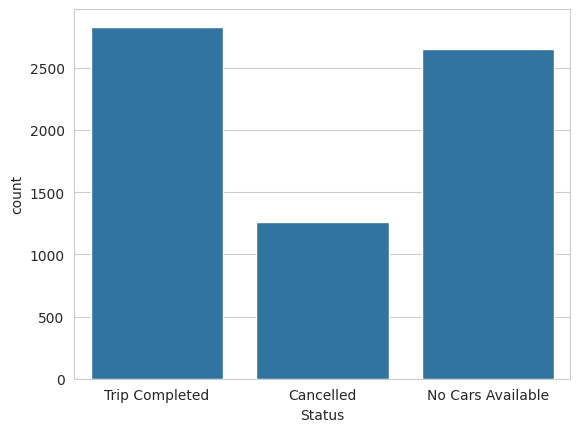

In [ ]:
sns.countplot(data=df, x='Status')


<Axes: xlabel='count', ylabel='Cab Availability'>

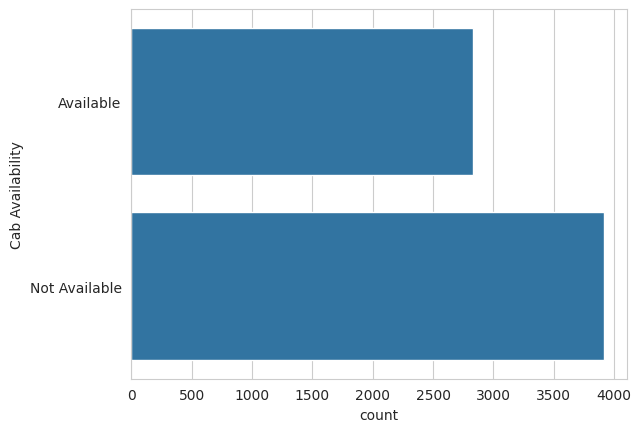

In [ ]:
sns.countplot(data=df, y='Cab Availability')

In [ ]:
df['Pickup point'].value_counts()

,count
Pickup point,
City,3507
Airport,3238


In [ ]:
df['Pickup point'].value_counts(normalize=True)

,proportion
Pickup point,
City,0.519941
Airport,0.480059


In [ ]:
df.groupby('RequestHour').size()

,0
RequestHour,
0,99
1,85
2,99
3,92
4,203
5,445
6,398
7,406
8,423


In [ ]:
df.groupby('RequestHour').size().reset_index(name ='Rides')

,RequestHour,Rides
0,0,99
1,1,85
2,2,99
3,3,92
4,4,203
5,5,445
6,6,398
7,7,406
8,8,423
9,9,431


<Axes: xlabel='RequestHour', ylabel='Rides'>

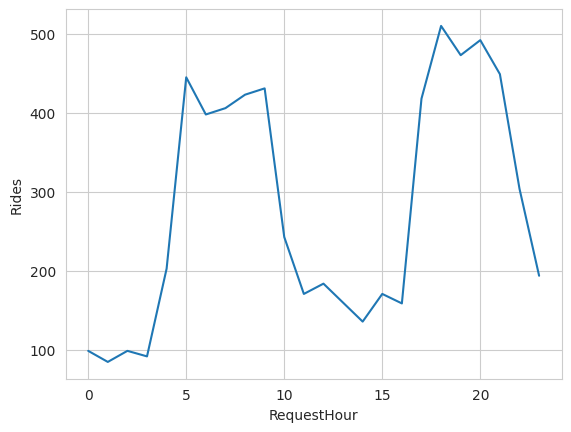

In [ ]:
sns.lineplot(data = df.groupby('RequestHour').size().reset_index(name ='Rides'), x ='RequestHour', y='Rides')

<Axes: xlabel='Pickup point', ylabel='count'>

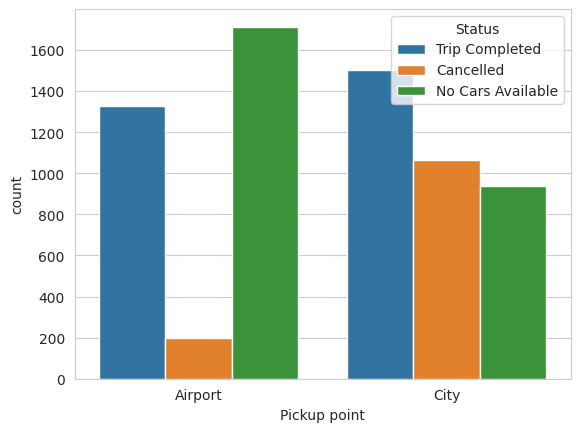

In [ ]:
sns.countplot(data=df, x='Pickup point', hue='Status')

In [ ]:
hourly_status =df.groupby(['RequestHour', 'Status']).size().unstack()

In [ ]:
airport_status = df[df['Pickup point'] == 'Airport'].groupby(['RequestHour', 'Status']).size().unstack()

<Axes: xlabel='RequestHour'>

<Figure size 1600x600 with 0 Axes>

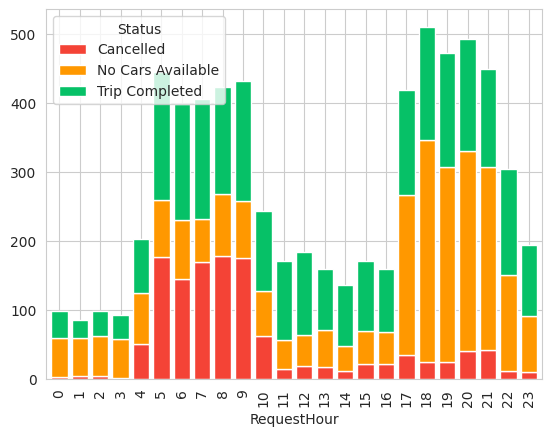

In [ ]:
plt.figure(figsize=(16, 6))
hourly_status.plot(
    kind='bar', stacked=True,
    color=['#F44336', '#FF9800', '#06C167'], width= 0.8)

<Axes: xlabel='RequestHour'>

<Figure size 1600x600 with 0 Axes>

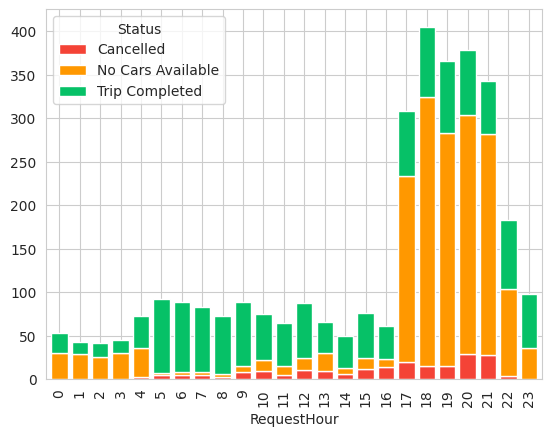

In [ ]:
plt.figure(figsize=(16, 6))
airport_status.plot(
    kind='bar', stacked=True,
    color=['#F44336', '#FF9800', '#06C167'], width= 0.8)

In [ ]:
city_status = df[df['Pickup point'] == 'City'].groupby(['RequestHour', 'Status']).size().unstack()

<Axes: xlabel='RequestHour'>

<Figure size 1600x600 with 0 Axes>

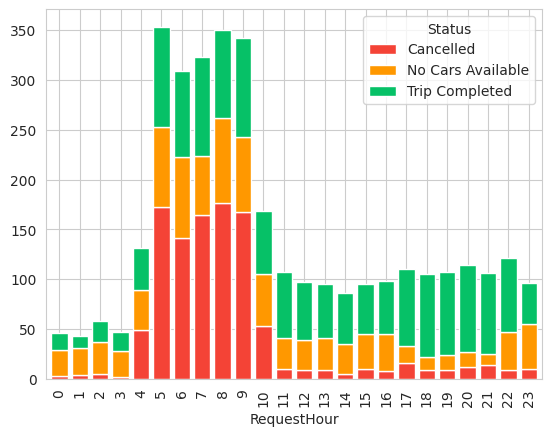

In [ ]:
plt.figure(figsize=(16, 6))
city_status.plot(
    kind='bar', stacked=True,
    color=['#F44336', '#FF9800', '#06C167'], width= 0.8)



```
`# This is formatted as code`
```



1. Airport Waiting
2. Shift Premium
3. Pre-position Fleet
4. Guarante Wider Airport Search

